In [2]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
data_url = "http://jse.amstat.org/v19n3/decock/AmesHousing.txt"
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
        'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv(data_url, sep="\t", usecols=columns)
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})
df = df.dropna(axis=0)

In [4]:
target = 'SalePrice'
features = df.columns[df.columns != target]

X = df[features].values
y = df[[target]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
slr = LinearRegression()
slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)
print(f"y_train_pred shape: {y_train_pred.shape}, y_test_pred shape: {y_test_pred.shape}")

y_train_pred shape: (2343, 1), y_test_pred shape: (586, 1)


np.float64(703377.77431498)

x_max: 703377.77431498
x_min: -72309.03906923739


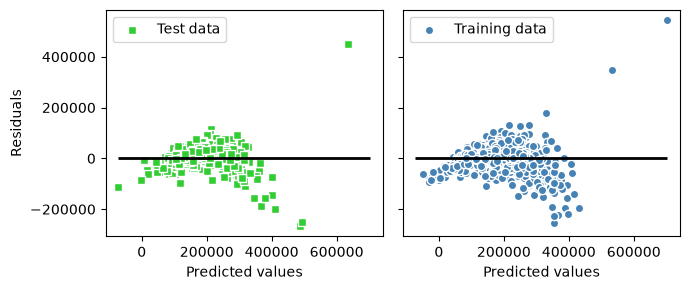

In [10]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
print(f"x_max: {x_max}")
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
print(f"x_min: {x_min}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Training data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='black', lw=2)

plt.tight_layout()

#plt.savefig('figures/09_11.png', dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE for training data: {mse_train:.3f}')
print(f'MSE for test data: {mse_test:.3f}')

Mean squared error (MSE) for training data: 1420901314.982
Mean squared error (MSE) for test data: 1817931757.893


In [ ]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'R^2 for training data: {r2_train:.3f}')
print(f'R^2 for test data: {r2_test:.3f}')